In [4]:
%load_ext autoreload
%autoreload 2 
    
from __init__ import PRP; import sys
sys.path.append(PRP + 'Diffusion_model')
sys.path.append(PRP + 'Results/analysis_scripts/')

import os
from configs.base_config import TrainingConfig
from pipelines.pipeline_tensor import DDPMPipeline_Tensor
from pipelines.State import Observer
import torch
from Diffusion_Model.pipelines.new_constraint import *
from DataLoader import get_dataloader, get_infos
from TransformFields import TransformationPipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
pwd

'/Users/emeunier/Desktop/Projets/DINO-Fusion/Results/notebooks'

In [6]:
model_path = f'{os.environ["OCEANDATA"]}/models/dino-fusion/tav0h83b/'
pipeline = DDPMPipeline_Tensor.from_pretrained(model_path).to('mps')

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

In [7]:
config = TrainingConfig()
config.data_file='/Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar'
observer = Observer('data', config)

Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


In [130]:
observer.normalizer.infos['mask']['toce'].sum(axis=(-2,-1))

tensor([  448,   448,   448,   448,   448,   448,   448,   448,   448,   448,
          448,   448,   448,   448,   448,   448,   448,   448,   448,   448,
          448,   448,   448,   448,   448,   448,   448,   448,   448,   448,
          448,   448,   448,   448,   448, 12338], device='mps:0')

In [8]:
tr = TransformationPipeline(get_infos(config.data_file), config.fields, config.normalisation, device='mps')
train_dataloader = get_dataloader(config.data_file, tr, batch_size=1)
idt = iter(train_dataloader)
data = next(idt)

Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


In [5]:
shape   = data.shape

In [6]:
shape

torch.Size([1, 37, 208, 64])

In [100]:
constraint = Constraint() #GradientConstraint(Beta(beta_init=0.1, beta_type='constant'))

projection = OptimProjection(MeanDensityProfile(observer=observer),eps=0.1, max_opt_steps=10)

gen = torch.rand_like(data)

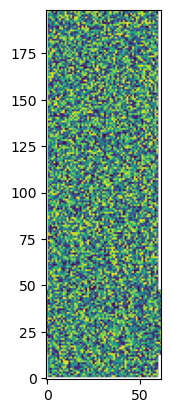

In [119]:
plt.imshow(observer.unnormalized(gen)['toce'][0,-1].cpu())

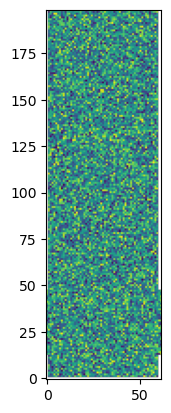

In [113]:
plt.imshow(observer.density(gen)[0,-1].cpu())

In [101]:
%%time
gen_new = projection(gen)

0.09298358857631683 3
CPU times: user 491 ms, sys: 119 ms, total: 610 ms
Wall time: 882 ms


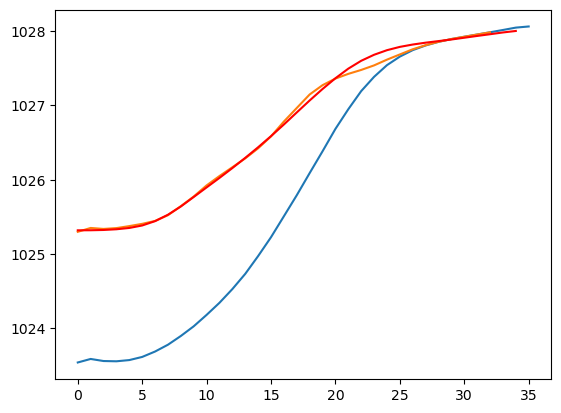

In [102]:
plt.plot(observer.density(gen).nanmean(axis=(-2, -1)).detach().cpu().T)
plt.plot(observer.density(gen_new).nanmean(axis=(-2, -1)).detach().cpu().T)
plt.plot(projection.loss.mean_density.cpu(), c='red')

In [106]:
gen.isnan().sum()

tensor(0, device='mps:0')

In [105]:
gen_new.isnan().sum()

tensor(23456, device='mps:0')

In [99]:
with torch.no_grad() :
    for t in pipeline.progress_bar(pipeline.scheduler.timesteps): #pipeline.scheduler.timesteps
        model_output = pipeline.unet(gen, t).sample
        increment_model = pipeline.scheduler.step(model_output, t, gen).prev_sample # x - dt* ∇log p(x) 
        
        constraint_dt = constraint(gen, t) # 𝛼∇C(x)
        
        gen = projection(increment_model - constraint_dt)
        print(f'{gen.isnan().sum()=}')

  0%|          | 0/1000 [00:00<?, ?it/s]

gen.isnan().sum()=tensor(0, device='mps:0')
gen.isnan().sum()=tensor(0, device='mps:0')
gen.isnan().sum()=tensor(0, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, device='mps:0')
gen.isnan().sum()=tensor(492544, de

KeyboardInterrupt: 

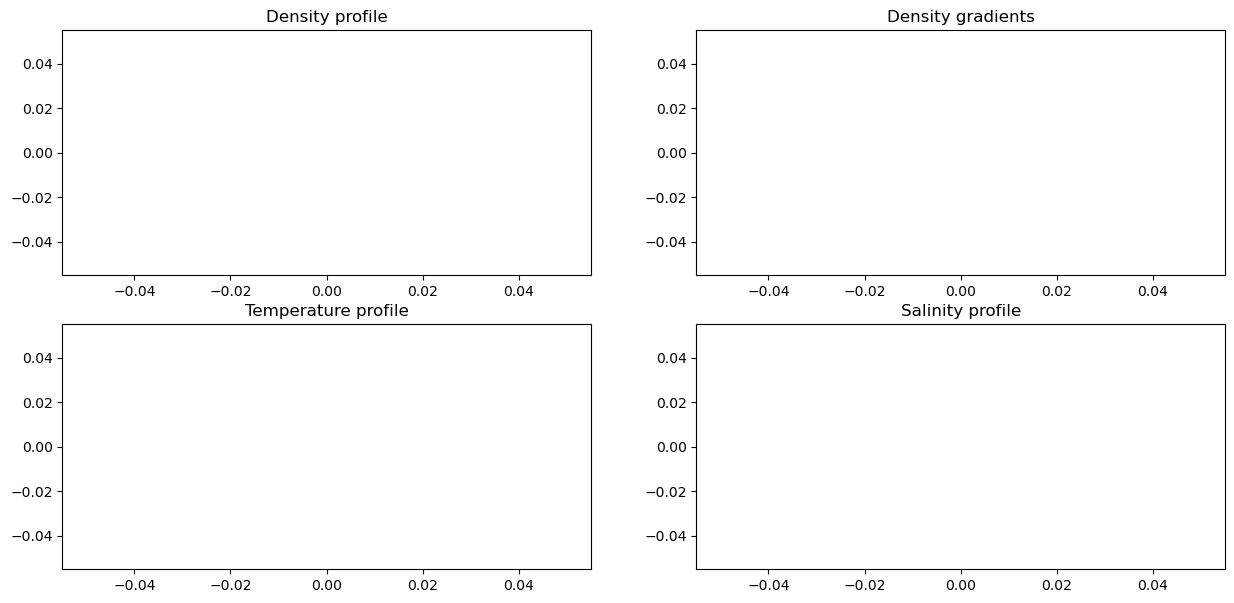

In [79]:
fig, axs = plt.subplots(2,2, figsize=(15,7))

#fig.suptitle(f'Generated profiles {Gen.name}')
axs[0, 0].set_title('Density profile')
axs[0, 0].plot(observer.density(gen).nanmean(axis=(-1,-2))[:, :-1].T.cpu())

axs[0, 1].set_title('Density gradients')
axs[0, 1].plot(observer.density_gradient(gen).nanmean(axis=(-1,-2))[:, :-1].T.cpu())

axs[1, 0].set_title('Temperature profile')
axs[1, 0].plot(observer.unnormalized(gen)['toce'].nanmean(axis=(-1,-2))[:, :-1].T.cpu())

axs[1, 1].set_title('Salinity profile')
axs[1, 1].plot(observer.unnormalized(gen)['soce'].nanmean(axis=(-1,-2))[:, :-1].T.cpu())

# SAL

In [209]:
constraint = Constraint() #GradientConstraint(Beta(beta_init=0.1, beta_type='constant'))

projection = OptimProjection(MeanGradDensityProfile(observer=observer),eps=0.1, max_opt_steps=10)

gen = torch.randn(*shape, device='mps')

In [ ]:
mu = torch.zeros_like(gen)
gen_z = projection(gen)
rho = 0.1
eta = 0.1

with torch.no_grad() :
    for t in pipeline.progress_bar(pipeline.scheduler.timesteps): #pipeline.scheduler.timesteps
        var = pipeline.scheduler._get_variance(t, None)**0.5

        # Step 1 :
        model_output = pipeline.unet(gen, t).sample
        gen = pipeline.scheduler.step(model_output, t, gen).prev_sample # x - dt* ∇log p(x) 
        gen -= rho * (gen - gen_z + mu)
        
        # Step 2 : 
        gen_z = projection(gen + mu + var * torch.randn_like(gen)) # ??

        # Step 3 : 
        mu += eta * (gen - gen_z)

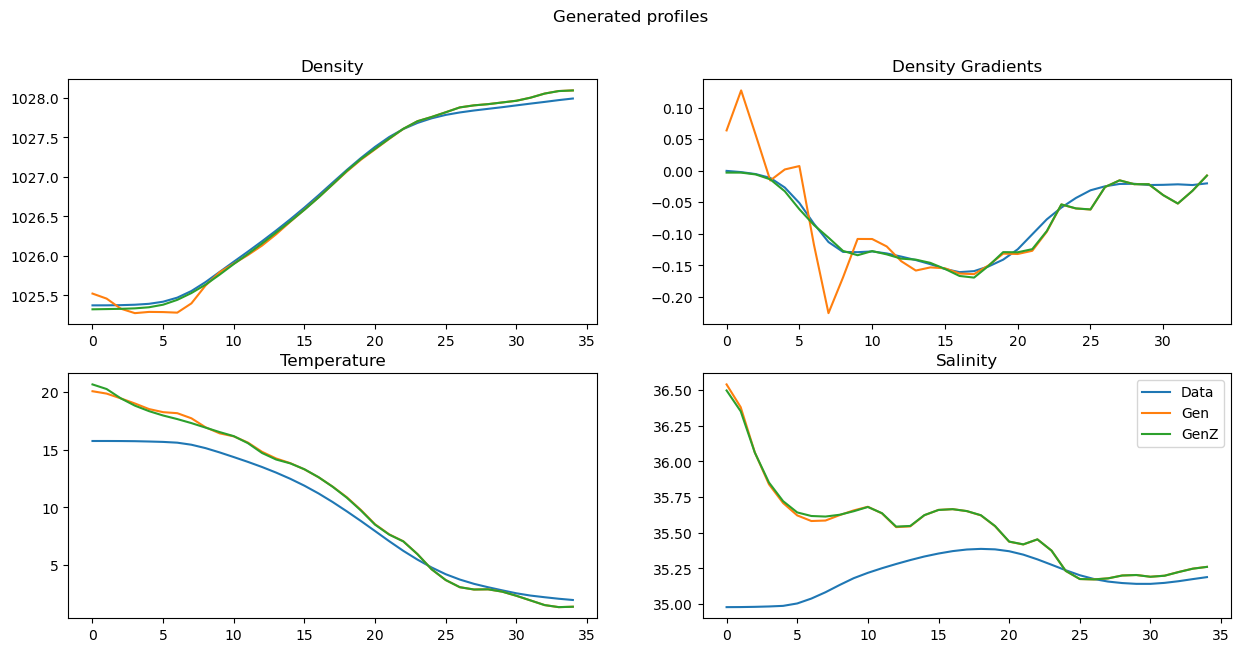

In [233]:
fig, axs = plt.subplots(2,2, figsize=(15,7))

fig.suptitle(f'Generated profiles')

funs = {'Density' : observer.density,
        'Density Gradients' :observer.density_gradient,
        'Temperature' : (lambda x : observer.unnormalized(x)['toce.npy']),
        'Salinity' : (lambda x : observer.unnormalized(x)['soce.npy'])}

fs = {'Data' : data, 'Gen' : gen, 'GenZ' : gen_z}

axs = axs.flatten()

for i, (k, v) in enumerate(funs.items()) : 
    axs[i].set_title(k)
    for fk, fv in fs.items() : 
        axs[i].plot(v(fv).nanmean(axis=(-1,-2))[:, :-1].T.cpu(), label=fk)
axs[-1].legend()

# Density Constraint

In [84]:
from copy import deepcopy
from tensordict.tensordict import TensorDict


In [51]:
gen = torch.randn(*shape, device='mps')

In [93]:
infos = deepcopy(observer.normalizer.infos)
infos['mean']['ssh'] = infos['mean']['ssh'][None]
infos['std']['ssh'] = infos['std']['ssh'][None]
infos_stride = {}
infos_stride['mean'] = observer.normalizer.stride_concat(infos['mean'])
infos_stride['std'] = observer.normalizer.stride_concat(infos['std'])
infos_stride = TensorDict(infos_stride, batch_size=[]).to(gen.device)

In [100]:
gen_unormalized = (gen * (3*infos_stride['std'][None])) + infos_stride['mean'][None]

In [101]:
infos_stride['mean'].shape

torch.Size([37, 1, 1])

In [106]:
infos['mean']

TensorDict(
    fields={
        soce: Tensor(shape=torch.Size([36, 1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        ssh: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        toce: Tensor(shape=torch.Size([36, 1, 1]), device=cpu, dtype=torch.float32, is_shared=False)},
    batch_size=torch.Size([]),
    device=None,
    is_shared=False)

In [103]:
gen_unormalized.shape

torch.Size([1, 37, 208, 64])

# SAL - Latent

In [36]:
from torch.autograd.functional import vjp

In [25]:
#Density constraint
density_profile_data = torch.tensor(np.loadtxt(f'{PRP}/Results/analysis_scripts/mean_density_train.txt'),
                                    device='mps', dtype=torch.float32)
g = lambda x : observer.density_profile(x)
projection = lambda g_x : density_profile_data[None, :].repeat((g_x.shape[0],1))
soft_projection = lambda g_x, alpha : alpha * density_profile_data[None, :].repeat((g_x.shape[0],1)) + (1-alpha) * g_x


# Temperature / Salinity 
#g = lambda x : x.nanmean(axis=(-2, -1))
#projection = lambda g_x : torch.zeros_like(g_x) # We want null mean

In [34]:
rho = 0.1
eta = 0.1

gen = torch.randn(*shape, device='mps')
mu = torch.zeros_like(g(gen))
gen_z = projection(g(gen))

In [29]:
for t in pipeline.progress_bar(pipeline.scheduler.timesteps): #
    var = pipeline.scheduler._get_variance(t, None)**0.5
    
    
    with torch.no_grad() :
        model_output = pipeline.unet(gen, t).sample
        gen = pipeline.scheduler.step(model_output, t, gen).prev_sample # x - dt* ∇log p(x) 
    
    g_x, dg_x_v =  vjp(g, gen, mu + g(gen) - gen_z)
    dg_x_v.nan_to_num_(0.0)
    
    gen -= rho * dg_x_v

    g_gen = g(gen)
    gen_z = projection(g_gen + mu + var * torch.randn_like(g_gen))
    
    mu += eta*(g_gen - gen_z)
    print(t, gen.isnan().sum(), gen.max(), gen.min())
    if gen.isnan().sum() > 0 : 
        break

  0%|          | 0/1000 [00:00<?, ?it/s]

tensor(999) tensor(0, device='mps:0') tensor(5.0235, device='mps:0') tensor(-4.4858, device='mps:0')
tensor(998) tensor(0, device='mps:0') tensor(4.7856, device='mps:0') tensor(-5.1115, device='mps:0')
tensor(997) tensor(0, device='mps:0') tensor(4.3616, device='mps:0') tensor(-4.6826, device='mps:0')
tensor(996) tensor(0, device='mps:0') tensor(4.8047, device='mps:0') tensor(-4.4906, device='mps:0')
tensor(995) tensor(0, device='mps:0') tensor(5.3558, device='mps:0') tensor(-4.9040, device='mps:0')
tensor(994) tensor(0, device='mps:0') tensor(4.9130, device='mps:0') tensor(-4.4545, device='mps:0')
tensor(993) tensor(0, device='mps:0') tensor(4.7898, device='mps:0') tensor(-4.7507, device='mps:0')
tensor(992) tensor(0, device='mps:0') tensor(4.6103, device='mps:0') tensor(-4.3749, device='mps:0')
tensor(991) tensor(0, device='mps:0') tensor(4.7728, device='mps:0') tensor(-4.8694, device='mps:0')
tensor(990) tensor(0, device='mps:0') tensor(4.7636, device='mps:0') tensor(-5.4175, device

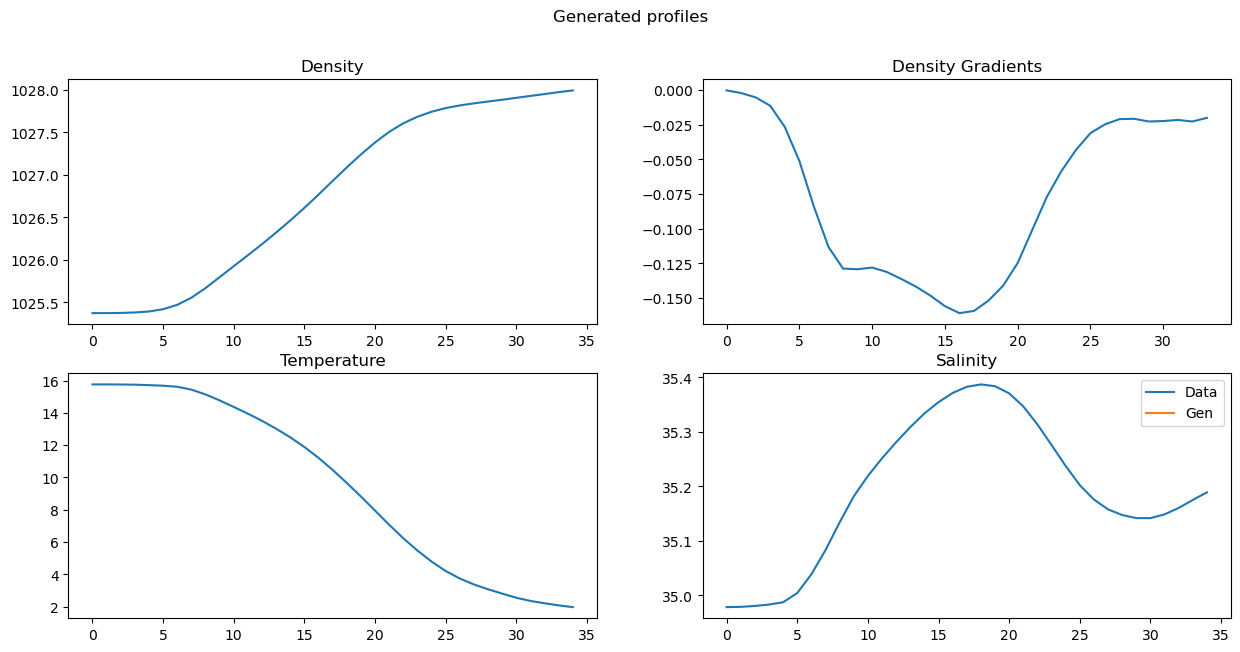

In [33]:
fig, axs = plt.subplots(2,2, figsize=(15,7))

fig.suptitle(f'Generated profiles')

funs = {'Density' : observer.density,
        'Density Gradients' :observer.density_gradient,
        'Temperature' : (lambda x : observer.unnormalized(x)['toce.npy']),
        'Salinity' : (lambda x : observer.unnormalized(x)['soce.npy'])}

fs = {'Data' : data, 'Gen' : gen}

axs = axs.flatten()

for i, (k, v) in enumerate(funs.items()) : 
    axs[i].set_title(k)
    for fk, fv in fs.items() : 
        axs[i].plot(v(fv).nanmean(axis=(-1,-2))[:, :-1].T.cpu(), label=fk)
axs[-1].legend()

In [20]:
projection(g(gen))

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0')